# Цифровые технологии в профессиональной деятельности
## Раздел 2. Деревья, сети, карты
## Семинар 6. Геоданные: храмы Москвы на карте

На прошлых занятиях мы работали с текстом: считали частоты, строили TF-IDF, подключались к API НКРЯ. Сегодня мы переходим к **нетекстовым данным** — географическим координатам.

**Материал:** датасет из записей с информацией о храмах Москвы: координаты, адреса, районы и ближайшие станции метро.

**Чему научимся:**
- Очищать табличные данные (`pandas`)
- Фильтровать, группировать, сортировать строки
- Строить интерактивные карты (`folium`)
- Визуализировать пространственное распределение

Рекомендуется запустить сразу все ячейки, чтобы карты прогрузились и вам было удобно следить за происходящим и выполнять задания.

In [38]:
# импорт библиотек
# pip install kagglehub[pandas-datasets]
# pip install folium

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

## Часть 1. Загрузка и первый взгляд на данные

URL датасета на Kaggle: https://www.kaggle.com/datasets/algord/religious-objects-in-moscow

In [39]:
# Загружаем данные
df = kagglehub.load_dataset(
     KaggleDatasetAdapter.PANDAS,
     "algord/religious-objects-in-moscow",
     "orthodox-churches.csv",
)

C:\Users\NYX\AppData\Local\Temp\ipykernel_17568\202195933.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [40]:
print(df.shape)
print(f"Размер таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов")

(551, 11)
Размер таблицы: 551 строк, 11 столбцов


In [41]:
print(df.columns.tolist())

['ID', 'Name', 'AdmArea', 'District', 'Address', 'MetroStation', 'MetroLine', 'PublicPhone', 'WebSite', 'Longitude_WGS84', 'Latitude_WGS84']


In [42]:
df.head()

,ID,Name,AdmArea,District,Address,MetroStation,MetroLine,PublicPhone,WebSite,Longitude_WGS84,Latitude_WGS84
0,1,Assumption Cathedral,Central Administrative District,Tver district,Kremlin,Lenin's Library,Sokolnica line,(495) 695-37-76,assumption-cathedral.kreml.ru,"37,617071","55,751012"
1,2,Cathedral of the Archangel,Central Administrative District,Tver district,Kremlin,Lenin's Library,Sokolnica line,(495) 695-37-76,archangel-cathedral.kreml.ru,"37,61783","55,75024"
2,3,Blagoveshchensky cathedral,Central Administrative District,Tver district,Kremlin,Lenin's Library,Sokolnica line,(495) 695-37-76,annunciation-cathedral.kreml.ru,"37,616949","55,750092"
3,4,Patriarchal Chambers with the Church of the Tw...,Central Administrative District,Tver district,Kremlin,Lenin's Library,Sokolnica line,(495) 695-37-76,www.kreml.ru/visit-to-kremlin/what-to-see/patr...,"37,617476","55,751416"
4,5,Temple of John Climacus with the bell tower of...,Central Administrative District,Tver district,Kremlin,Lenin's Library,Sokolnica line,(495) 695-37-77,ivan-the-great-bell-tower.kreml.ru,"37,618317","55,750763"


In [43]:
# Какого типа данные в каждом столбце?
# .dtypes показывает тип каждого столбца:
#   int64 = целое число
#   float64 = дробное число
#   object или str = текст

df.dtypes

ID                  int64
Name               object
AdmArea            object
District           object
Address            object
MetroStation       object
MetroLine          object
PublicPhone        object
WebSite            object
Longitude_WGS84    object
Latitude_WGS84     object
dtype: object

Обратите внимание: столбцы `Longitude_WGS84` и `Latitude_WGS84` имеют тип `object`, а не `float64`: координаты записаны как текст — мы не можем использовать их для вычислений и карт, пока не преобразуем в числа.

## Часть 2. Очистка данных

### Проблема с координатами

В нашем файле десятичный разделитель — **запятая** (`37,617071`), а Python ожидает **точку** (`37.617071`), давайте исправлять.

In [44]:
# Посмотрим на координаты до исправления
print("До исправления:")
print(df['Longitude_WGS84'].head(3))
print(type(df['Longitude_WGS84'].iloc[0]))

До исправления:
0    37,617071
1     37,61783
2    37,616949
Name: Longitude_WGS84, dtype: object
<class 'str'>


In [45]:
# Исправляем: заменяем запятую на точку и преобразуем в число.
# .str.replace(',', '.') — строковая замена символа
# .astype(float) — преобразуем строку в дробное число

df['lon'] = df['Longitude_WGS84'].str.replace(',', '.').astype(float)
df['lat'] = df['Latitude_WGS84'].str.replace(',', '.').astype(float)

print("После исправления:")
print(df[['lon', 'lat']].head(3))
print(type(df['lon'].iloc[0]))

После исправления:
         lon        lat
0  37.617071  55.751012
1  37.617830  55.750240
2  37.616949  55.750092
<class 'numpy.float64'>


### Проверка на пропуски

Прежде чем анализировать данные, нужно понять, есть ли пропуски значений. Пропущенные значения (`NaN`) могут ломать вычисления.

In [46]:
# .isnull().sum() считает количество пропусков в каждом столбце
df.isnull().sum()

ID                   0
Name                 0
AdmArea              0
District             0
Address              0
MetroStation         0
MetroLine            0
PublicPhone         33
WebSite            128
Longitude_WGS84      0
Latitude_WGS84       0
lon                  0
lat                  0
dtype: int64

In [47]:
# альтернативный вариант проверки

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551 entries, 0 to 550
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               551 non-null    int64  
 1   Name             551 non-null    object 
 2   AdmArea          551 non-null    object 
 3   District         551 non-null    object 
 4   Address          551 non-null    object 
 5   MetroStation     551 non-null    object 
 6   MetroLine        551 non-null    object 
 7   PublicPhone      518 non-null    object 
 8   WebSite          423 non-null    object 
 9   Longitude_WGS84  551 non-null    object 
 10  Latitude_WGS84   551 non-null    object 
 11  lon              551 non-null    float64
 12  lat              551 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 56.1+ KB


Пропуски есть только в `PublicPhone` и `WebSite` — это не критично для нашего анализа. Координаты и названия полные.

#### Задание 1 (разминка)

Используя методы pandas, ответьте на вопросы:
1. Сколько уникальных административных округов (`AdmArea`) в датасете?
2. Сколько уникальных районов (`District`)?
3. Выведите список линий метро (`MetroLine`).

Используйте: `.nunique()`, `.unique()`

In [48]:
# ВАШ КОД


## Часть 3. Работаем с таблицей: фильтрация, группировка, сортировка

### Фильтрация строк

Фильтрация — это выбор строк, которые удовлетворяют условию. В pandas условие записывается внутри квадратных скобок.

In [49]:
# Выбираем только храмы Центрального округа
center = df[df['AdmArea'] == 'Central Administrative District']

print(f"Храмов в Центральном округе: {len(center)}")
print(f"Это {len(center) / len(df) * 100:.1f}% от всех храмов Москвы")

Храмов в Центральном округе: 203
Это 36.8% от всех храмов Москвы


Маски более чем из одного условия удобнее выносить в отдельные переменные.

In [50]:
condition = df['AdmArea'] == 'Central Administrative District'
center = df[condition] # привычнее condition называть mask

print(f"Храмов в Центральном округе: {len(center)}")
print(f"Это {len(center) / len(df) * 100:.1f}% от всех храмов Москвы")

Храмов в Центральном округе: 203
Это 36.8% от всех храмов Москвы


### Операторы фильтрации

Условия можно комбинировать с помощью операторов. В pandas для сравнения строк доступны следующие операторы:

| Оператор | Смысл |
|----------|-------|
| `==` | равно |
| `!=` | не равно |
| `>`, `<`, `>=`, `<=` | больше / меньше (для чисел) |
| `&` | И (оба условия должны выполняться) |
| `\|` | ИЛИ (хотя бы одно) |
| `.isin([...])` | значение входит в список |
| `.str.contains(...)` | строка содержит подстроку |
| `~` | отрицание (NOT) |

Каждый из них возвращает столбец из `True` / `False` — **маску**. DataFrame в квадратных скобках оставляет только строки, где маска равна `True`.

In [51]:
# Храмы Тверского района на Сокольнической линии
mask = (df['District'] == 'Tver district') & (df['MetroLine'] == 'Sokolnica line') # каждое условие обрамляется круглыми скобками, каждое можно писать на отдельной строке для удобства чтения

tver_sokol = df[mask]
print(f"Храмов в Тверском районе у Сокольнической линии: {len(tver_sokol)}")
tver_sokol[['Name', 'Address']].head()

Храмов в Тверском районе у Сокольнической линии: 10


,Name,Address
0,Assumption Cathedral,Kremlin
1,Cathedral of the Archangel,Kremlin
2,Blagoveshchensky cathedral,Kremlin
3,Patriarchal Chambers with the Church of the Tw...,Kremlin
4,Temple of John Climacus with the bell tower of...,Kremlin


In [52]:
# != — исключить строки с конкретным значением
# Все храмы, кроме Центрального округа
mask = df['AdmArea'] != 'Central Administrative District'

not_center = df[mask]
print(f"Храмов вне Центрального округа: {len(not_center)}")

Храмов вне Центрального округа: 348


In [53]:
# ~ — то же самое через отрицание маски (эквивалентная запись)
mask = df['AdmArea'] == 'Central Administrative District'
not_center_v2 = df[~mask]
print(f"Результат через ~: {len(not_center_v2)}")

Результат через ~: 348


In [54]:
# .isin() — выбрать строки, где значение входит в список
# Удобно, когда условий несколько и писать цепочку == / | неудобно

target_lines = ['Sokolnica line', 'Zamoskvoretskaya line', 'Kaluga-Riga line']
mask = df['MetroLine'].isin(target_lines)
central_lines = df[mask]

print(f"Храмов у трёх центральных линий: {len(central_lines)}")
central_lines['MetroLine'].value_counts()

Храмов у трёх центральных линий: 255


MetroLine
Kaluga-Riga line         111
Sokolnica line            96
Zamoskvoretskaya line     48
Name: count, dtype: int64

In [55]:
# .str.contains() — True, если строка содержит указанную подстроку
# Полезно для поиска по частичному совпадению, когда не знаешь точного значения
# na=False — пропуски не вызывают ошибку, а засчитываются как False

mask = df['Name'].str.contains('Cathedral', na=False)
cathedral = df[mask]
print(f"Объектов с 'Cathedral' в названии: {len(cathedral)}")
cathedral[['Name', 'Address']].head(6)

Объектов с 'Cathedral' в названии: 12


,Name,Address
0,Assumption Cathedral,Kremlin
1,Cathedral of the Archangel,Kremlin
5,Verkhospassky Cathedral (Savior of a Miraculou...,Kremlin
7,The temple of the Protection of the Blessed Vi...,"Red Square, house 2"
8,Epiphany Cathedral,"Spartakovskaya street, house 15"
9,Cathedral Cathedral Cathedral of Christ the Sa...,"Volkhonka street, house 15"


In [56]:
# Числовые условия работают с координатами.
# Долгота Москвы: примерно 37.3 (запад) — 37.9 (восток).
# Отберём храмы в западной половине города (lon < 37.62 — меридиан Кремля)

west = df[df['lon'] < 37.62]
east = df[df['lon'] >= 37.62]
print(f"Западная часть: {len(west)} храмов")
print(f"Восточная часть: {len(east)} храмов")

# | — ИЛИ: храмы либо в Северном, либо в Северо-Западном округе
north = df[
    (df['AdmArea'] == 'Northern Administrative District') |
    (df['AdmArea'] == 'North-Western Administrative District')
]
print(f"\nХрамов в северных округах: {len(north)}")

Западная часть: 312 храмов
Восточная часть: 239 храмов

Храмов в северных округах: 29


#### Задание 2

Используя операторы фильтрации:

1. Найдите все храмы, в названии которых есть слово `"Trinity"`.
2. Отберите храмы из **двух** округов на ваш выбор с помощью `.isin()`.
3. Сколько храмов расположено **севернее** широты 55.85? (столбец `lat`)

Подсказка: для задания 3 используйте числовое сравнение с `df['lat']`.

### Группировка и подсчёт

`.value_counts()` считает, сколько раз встречается каждое значение. 
`.groupby()` позволяет группировать данные и вычислять агрегаты (среднее, сумму, количество).

In [57]:
# Сколько храмов в каждом округе?
# .value_counts() — считает количество повторений каждого значения
df['AdmArea'].value_counts()

AdmArea
Central Administrative District          203
Southern Administrative District          42
Western administrative district           40
North-eastern administrative district     40
Eastern administrative district           39
South-Western administrative district     38
Novomoskovsky Administrative District     35
Southeast administrative district         35
Northern Administrative District          29
Trinity Administrative District           28
North-Western administrative district     19
Zelenograd administrative district         3
Name: count, dtype: int64

In [58]:
# То же самое, но через groupby:
# .groupby('столбец').size() — группирует строки по значению столбца
# и считает количество строк в каждой группе.
# .sort_values(ascending=False) — сортирует по убыванию.
df.groupby('AdmArea').size().sort_values(ascending=False)

AdmArea
Central Administrative District          203
Southern Administrative District          42
Western administrative district           40
North-eastern administrative district     40
Eastern administrative district           39
South-Western administrative district     38
Southeast administrative district         35
Novomoskovsky Administrative District     35
Northern Administrative District          29
Trinity Administrative District           28
North-Western administrative district     19
Zelenograd administrative district         3
dtype: int64

In [59]:
# Можно группировать сразу по нескольким столбцам.
# Получим таблицу: сколько храмов в каждом округе на каждой линии метро.

by_area_line = (
    df.groupby(['AdmArea', 'MetroLine']) 
    .size() # по умолчанию возвращает объект типа Series со сложным двухэтапным индексом
    .reset_index(name='count')   # сбрасывает сложный индекс, превращая «AdmArea» и «MetroLine» в обычные столбцы, а результаты подсчета записывает в новый столбец
    .sort_values('count', ascending=False)
)

by_area_line.head(10)

,AdmArea,MetroLine,count
7,Central Administrative District,Sokolnica line,42
3,Central Administrative District,Kaluga-Riga line,36
5,Central Administrative District,Ring line,29
6,Central Administrative District,Serpukhov-Timiryazevsky line,26
29,South-Western administrative district,Kaluga-Riga line,25
0,Central Administrative District,Arbat-Pokrovskaya line,22
17,North-eastern administrative district,Kaluga-Riga line,20
34,Southeast administrative district,Lublin-Dmitrov line,18
46,Western administrative district,Arbat-Pokrovskaya line,18
41,Southern Administrative District,Zamoskvoretskaya line,18


#### Задание 3

1. Найдите 5 районов (`District`) с наибольшим числом храмов.
2. На какой линии метро (`MetroLine`) больше всего храмов?
3. Отфильтруйте храмы, у которых **нет** веб-сайта (`WebSite` пропущен). Сколько их?

Подсказка для пункта 3: `.isnull()` возвращает `True` для пропущенных значений.

In [60]:
# ВАШ КОД


### Перекрёстная таблица: округ × линия метро

`pd.crosstab()` создаёт таблицу сопряжённости — сколько храмов в каждом сочетании округа и линии метро.

In [ ]:
# Перекрёстная таблица
cross = pd.crosstab(df['AdmArea'], df['MetroLine'])

# Сократим названия для читаемости
cross.index = [n.replace(' Administrative District', '').replace(' administrative district', '') for n in cross.index]
cross.columns = [n.replace(' line', '') for n in cross.columns]

cross

,Arbat-Pokrovskaya,Butovo of the light metro,Filev,Kakhovskaya,Kalinin,Kaluga-Riga,Lublin-Dmitrov,Ring,Serpukhov-Timiryazevsky,Sokolnica,Tagansko-Krasnopresnenskaya,Zamoskvoretskaya
Central,22,0,11,0,5,36,10,29,26,42,14,8
Eastern,10,0,0,0,6,0,0,0,0,16,7,0
North-Western,6,0,0,0,0,0,0,0,0,0,12,1
North-eastern,0,0,0,0,0,20,3,0,17,0,0,0
Northern,0,0,0,0,0,0,0,0,8,0,4,17
Novomoskovsky,0,5,1,0,0,14,0,0,4,11,0,0
South-Western,0,0,0,4,0,25,0,0,6,3,0,0
Southeast,2,0,0,0,5,0,18,0,0,0,9,1
Southern,0,0,0,4,0,5,3,0,12,0,0,18
Trinity,1,0,0,0,0,11,0,0,10,6,0,0


#### Задание 4

Используя перекрёстную таблицу или другие средства pandas:

1. Какой округ обслуживается наибольшим числом линий метро?
2. Есть ли линия метро, храмы рядом с которой принадлежат **только одному** округу?

Подсказка: в перекрёстной таблице ненулевые значения означают, что в данном сочетании есть хотя бы один храм. Можно использовать `(cross > 0).sum()` для подсчёта.

In [ ]:
# ВАШ КОД

## Часть 4. Визуализация: столбчатые диаграммы

Прежде чем переходить к картам, построим привычные графики — посмотрим, как распределены храмы по округам.

In [61]:
# Считаем количество храмов по округам
counts = df['AdmArea'].value_counts()

# Для удобства сократим названия (убираем "Administrative District")
counts.index = [name.replace(' Administrative District', '').replace(' administrative district', '')
                for name in counts.index]

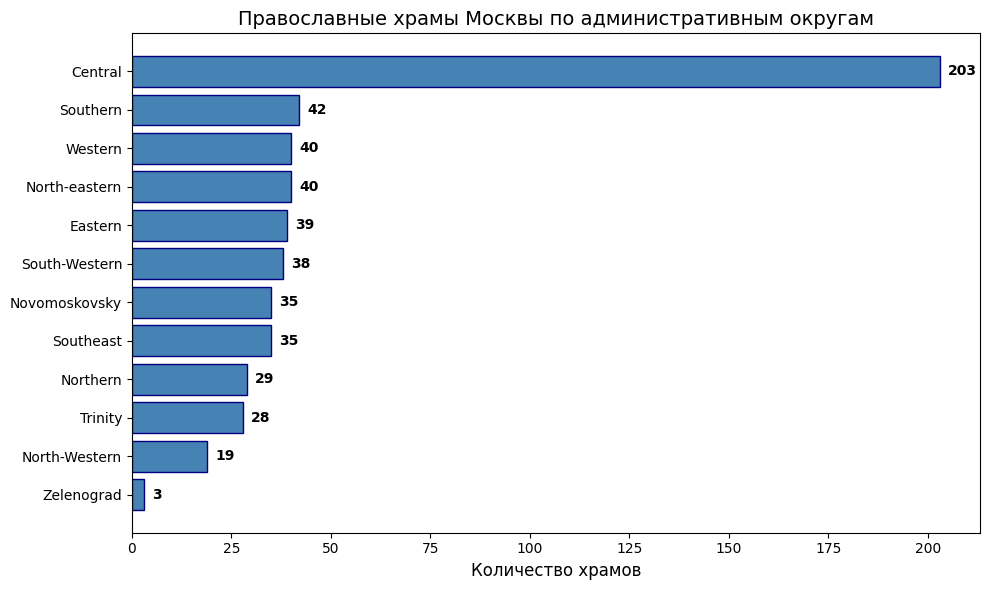

In [62]:
# ===== ГОРИЗОНТАЛЬНАЯ СТОЛБЧАТАЯ ДИАГРАММА =====
# plt.barh() — горизонтальные столбцы (удобнее, когда подписи длинные)
plt.figure(figsize=(10, 6))
plt.barh(counts.index, counts.values, color='steelblue', edgecolor='navy')

# Подписи значений на концах столбцов
for i, v in enumerate(counts.values):
    plt.text(v + 2, i, str(v), va='center', fontweight='bold')

plt.xlabel('Количество храмов', fontsize=12)
plt.title('Православные храмы Москвы по административным округам', fontsize=14)
plt.gca().invert_yaxis()  # чтобы самый большой округ был сверху
plt.tight_layout()
plt.show()

## Часть 5. Интерактивная карта: folium

Перед тем как перейти к коду, важно понять базовый принцип работы современных веб-карт, таких как Яндекс Карты, Google Maps или карты [OpenStreetMap](https://www.openstreetmap.org/#map=7/52.154/5.295), которые мы будем использовать.

Большинство интерактивных карт в браузере состоят из трех основных слоев:

1. **Тайлы (плитки подложки):** если бы компьютер загружал всю карту мира одновременно в максимальном разрешении, это заняло бы слишком много памяти. Поэтому веб-карты разрезаются на небольшие квадратные изображения — **тайлы** (обычно размером 256x256 пикселей). Когда вы двигаете карту или меняете масштаб, браузер мгновенно подгружает только те квадраты, которые попадают в область видимости. Сама карта при этом остается плоской растровой картинкой.

2. **Векторный слой (наши данные):** поверх готовой картиночной подложки накладываются географические объекты, координаты которых мы передаем из нашего датафрейма. Это могут быть точки (маркеры храмов), линии (маркёры маршрутов) или полигоны (границы районов). Браузер сам высчитывает, в каком месте экрана должна отобразиться точка с конкретной широтой и долготой.

3. **Интерактивный интерфейс:** слой логики (написанный на языке JavaScript), который обрабатывает клики мышкой, масштабирование колесиком и открывает всплывающие окна (`popup`) с текстовой информацией.

Мы будем использовать библиотеку **Folium**, инструмент, который позволяет нам писать простой код на Python, а затем сам превращает его в сложную интерактивную веб-страницу на базе популярной JavaScript-библиотеки **Leaflet.js**.

### Пустая карта

Всё начинается с создания объекта карты: указываем центр и масштаб.

In [63]:
# Создаём карту, центрированную на Москве.
# location=[широта, долгота] — центр карты
# zoom_start=11 — начальный масштаб (чем больше, тем ближе)
m = folium.Map(
    location=[55.7558, 37.6173],
    zoom_start=12,
    tiles='OpenStreetMap',
    control_scale=True,
)

# В Jupyter карта отображается, если просто написать имя переменной
m

`location` (географический центр карты) определяет точку на Земле, которая окажется ровно по центру экрана при загрузке. Параметр принимает список из двух числовых значений в формате [широта, долгота] (Latitude, Longitude) в десятичных градусах.

Широта показывает положение точки относительно **экватора** (север/юг), а долгота — относительно **Гринвичского меридиана** (восток/запад). 

Координаты [55.7558, 37.6173] указывают на **исторический центр Москвы**. Если перепутать числа местами, карта откроется в Индийском океане, так как широта географически не может превышать 90 градусов.

---

`zoom_start` (начальный масштаб) задает уровень приближения карты при ее первом отображении. Принимает целые числа (от 0 до 18). Масштаб в веб-картографии работает дискретно:

* 0 — максимальное отдаление (виден весь мир).
* 4 — масштаб континента или крупной страны.
* 10 — масштаб мегаполиса или городской агломерации.
* 15 — масштаб нескольких жилых кварталов.

Для визуализации объектов в пределах Москвы значение 11 является оптимальным, так как город целиком помещается в границы экрана.

---

`tiles` (стиль картографической подложки) определяет графический слой (картинку), поверх которого будут наноситься наши исследовательские данные. По умолчанию используется `'OpenStreetMap'` — подробная карта со всеми дорогами и подписями. Если подложка кажется слишком пестрой и отвлекает от анализа точек, ее можно заменить на нейтральную светлую `'CartoDB positron'`.

---

`control_scale` (масштабная линейка) принимает логическое значение `True` или `False`. Включение этого параметра (`True`) добавляет в угол карты классическую шкалу масштаба (в метрах и километрах). В исследовательской картографии это правило хорошего тона, помогающее визуально оценить реальные расстояния между объектами при изменении зума.

---

Размер карты можно регулировать параметрами `width` и `height`.

### Добавляем маркеры

Маркер — это точка на карте. Каждому маркеру можно добавить подпись (`popup`), которая появляется при клике.

In [64]:
# Добавим один маркер — Храм Христа Спасителя

folium.Marker(
    location=[55.7415, 37.6247],
    popup='Храм иконы Божией Матери "Всех скорбящих Радость"',
    tooltip='Кликните, чтобы узнать название',
    icon=folium.Icon(color='blue', icon='info-sign')
).add_to(m)

m

`popup` (всплывающее окно) контент, который появляется при клике мышкой по маркеру. Сюда передается строка с подробной информацией (название храма, адрес, историческая справка). Текст внутри popup поддерживает простейшие теги HTML, что позволяет форматировать текст (делать его жирным <b>...</b>) или вставлять рабочие гиперссылки.

---

`tooltip` (всплывающая подсказка) короткий текст, который мгновенно появляется при наведении курсора мыши на маркер (без клика). Удобно использовать для быстрых указаний (например, «Посмотреть детали»), чтобы пользователю не приходилось прокликивать каждую точку для первичного ознакомления с картой.

---

`icon` (внешний вид иконки) конструкция `folium.Icon()` позволяет кастомизировать маркер, меняя его цвет (color='blue') и внутренний графический символ (icon='info-sign'). Использование разных цветов — первый шаг к классификации объектов на карте (например, можно разделить объекты по векам постройки или архитектурным стилям).

---

Метод `.add_to(m)` команда, которая связывает созданный маркер с нашей картой `m`. Без вызова этого метода объект точки будет создан в оперативной памяти Python, но на самой карте не отобразится.

### Справочник бесплатных подложек (tiles) и иконок (icon) для Folium

Для кастомизации карт можно использовать готовые встроенные стили или подключать внешние открытые картографические серверы. Все приведенные ниже варианты бесплатны и не требуют регистрации.

---

#### 1. Варианты подложек (параметр `tiles`)

##### Встроенные стили (не требуют дополнительных параметров)
* **`tiles='OpenStreetMap'`** — стандартная подложка по умолчанию. Высокая детализация, но из-за обилия современных городских подписей и дорог может выглядеть избыточно.
* **`tiles='CartoDB positron'`** — светлая, минималистичной формы («немая») карта. Почти серые тона и приглушенные надписи делают её **лучшим выбором для демонстрации исследования**. На ней хорошо видны любые цветные маркеры и тепловые карты.
* **`tiles='CartoDB dark_matter'`** — темная (ночная) минималистичная подложка. Отлично подходит для создания контрастных визуализаций или карт с неоновыми маркерами.

##### Внешние стили (требуют указания URL и параметра `attr`)
Чтобы подключить стороннюю карту, в `tiles` передается ссылка-шаблон, а в обязательный параметр `attr` — текст с указанием авторских прав (требование картографических сервисов). Например:

* **Гуманитарная карта (OpenStreetMap Humanitarian)**

In [65]:
 # Вариант OSM с измененной цветовой схемой (пастельные, более мягкие цвета), ориентированный на социальные и исторические объекты.
tiles_url = 'https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png'
attr_text = '© OpenStreetMap contributors, Humanitarian OpenStreetMap Team'
folium.Map(location=[55.75, 37.62], zoom_start=11, tiles=tiles_url, attr=attr_text)

---

#### 2. Варианты оформления маркеров (класс `folium.Icon`)

Класс `folium.Icon()` позволяет менять цвет самого маркера («капли») и значок внутри него.

##### Доступные цвета (`color=...`)
В `folium` встроен ограниченный набор стандартных цветов для маркеров. Использование других названий вызовет ошибку. Доступные варианты:
* `'blue'` (синий, идет по умолчанию)
* `'red'` (красный)
* `'green'` (зеленый)
* `'purple'` (пурпурный)
* `'orange'` (оранжевый)
* `'darkred'`, `'lightred'` (темно- и светло-красный)
* `'darkblue'`, `'lightblue'` (темно- и светло-синий)
* `'darkgreen'`, `'lightgreen'` (темно- и светло-зеленый)
* `'black'`, `'white'`, `'gray'`, `'lightgray'` (черный, белый, серый, светло-серый)
* `'beige'` (бежевый)
* `'pink'` (розовый)
* `'cadetblue'` (морская волна)

##### Внутренние иконки (`icon=...`)
По умолчанию `folium` ищет значки в бесплатной библиотеке **Glyphicons** (встроена в Bootstrap). Чтобы выбрать иконку, нужно передать её имя в параметр `icon`.

Полезные для гуманитарных и городских исследований базовые значки:
* `icon='info-sign'` — знак информации (круг с буквой *i*)
* `icon='home'` — домик (подходит для зданий, усадеб)
* `icon='book'` — книга (библиотеки, школы, архивы)
* `icon='flag'` — флаг (исторические места, вехи)
* `icon='star'` — звезда (памятники, особо важные объекты)
* `icon='question-sign'` — вопросительный знак (неподтвержденные данные или объекты под вопросом)
* `icon='search'` — лупа
* `icon='time'` — часы (можно использовать для хронологических маркеров)

Пример использования:
```python
folium.Marker(
    location=[55.7415, 37.6256],
    icon=folium.Icon(color='purple', icon='star')
).add_to(m)

По умолчанию `folium` настроен на работу со встроенным набором `Glyphicons` (`Bootstrap 3`). Если этот параметр не указывать или написать `prefix='glyphicon'`, библиотека будет искать значок в стандартном наборе. Однако этот набор довольно ограничен и содержит мало специфических символов (например, там нет иконки храма или книги).

Чтобы использовать более современные и разнообразные шрифтовые иконки, в параметре prefix указывают альтернативные библиотеки. Два наиболее популярных варианта:

1. **Font Awesome** (`prefix='fa'`). В ней есть значок `church`, а также множество других полезных символов (`book`, `graduation-cap`, `map-marker` и т.д.).
2. **Ionicons** (`prefix='ion'`).

### Все храмы на карте

Теперь добавим все 551 храм. Для этого пройдём циклом по строкам DataFrame.

In [66]:
# Создаём карту
m = folium.Map(location=[55.75, 37.62], zoom_start=11)

# Проходим по каждой строке датафрейма.
# .iterrows() возвращает пары (индекс, строка).
for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,                   # размер кружка в пикселях
        color='darkblue',           # цвет обводки
        fill=True,                  # заливка
        fill_color='blue',          # цвет заливки
        fill_opacity=0.6,           # прозрачность заливки (0–1)
        popup=row['Name']           # название при клике
    ).add_to(m)

print(f"Добавлено {len(df)} маркеров")
m

Добавлено 551 маркеров


#### Задание 5

Постройте карту, на которой отмечены **только храмы Центрального округа**, измените подложку, цвет маркеров, их иконку, размер, а также размер самой карты.

Подсказка: сначала отфильтруйте DataFrame, потом пройдите циклом.

Отправьте скриншот карты в чат.

In [67]:
# ВАШ КОД


### Сохранение карты в HTML

Любую карту folium можно сохранить как самостоятельный HTML-файл — его можно открыть в браузере или отправить другому человеку без Jupyter.

In [68]:
m.save('temples_moscow_tmp.html')
print("Карта сохранена в temples_moscow_tmp.html")

Карта сохранена в temples_moscow_tmp.html


## Часть 6. Раскраска маркеров по категории

Чтобы увидеть, как храмы распределены по округам, раскрасим маркеры в разные цвета.

In [69]:
1 % 12

1

In [70]:
# Словарь: округ -> цвет
# Цвета должны быть из набора, который поддерживает folium:
# 'red', 'blue', 'green', 'purple', 'orange', 'darkred',
# 'lightred', 'beige', 'darkblue', 'darkgreen', 'cadetblue',
# 'darkpurple', 'white', 'pink', 'lightblue', 'lightgreen',
# 'gray', 'black', 'lightgray'

colors = {}
available_colors = ['red', 'blue', 'green', 'purple', 'orange',
                    'darkred', 'cadetblue', 'darkgreen', 'pink',
                    'lightblue', 'darkpurple', 'lightgreen']

for i, area in enumerate(df['AdmArea'].unique()):
    colors[area] = available_colors[i % len(available_colors)]

print("Цвета округов:")
for area, color in colors.items():
    print(f"  {area:<38} : {color}")

Цвета округов:
  Central Administrative District        : red
  North-Western administrative district  : blue
  Southern Administrative District       : green
  Western administrative district        : purple
  South-Western administrative district  : orange
  Southeast administrative district      : darkred
  Northern Administrative District       : cadetblue
  Eastern administrative district        : darkgreen
  Zelenograd administrative district     : pink
  Novomoskovsky Administrative District  : lightblue
  Trinity Administrative District        : darkpurple
  North-eastern administrative district  : lightgreen


In [71]:
# Карта с раскраской по округам
m = folium.Map(location=[55.75, 37.62], zoom_start=11)

for idx, row in df.iterrows():
    color = colors.get(row['AdmArea'], 'gray')
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"{row['Name']}<br>{row['AdmArea']}"
    ).add_to(m)

m

### HTML в popup

`folium.Popup` принимает произвольный HTML — можно добавить форматирование, ссылку на сайт, несколько строк информации.

In [72]:
m_popup = folium.Map(location=[55.75, 37.62], zoom_start=14)

# Возьмём только первые 30 храмов для наглядности
for _, row in df.head(30).iterrows():
    
    popup_html = f"""
    <div style="font-family: Arial; font-size: 13px; width: 220px">
        <b>{row['Name']}</b><br>
        📍 {row['Address']}<br>
        🚇 {row['MetroStation']}<br>
    </div>
    """
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=row['Name'],
    ).add_to(m_popup)

m_popup

### MarkerCluster — кластеризация маркеров

При 551 точках карта перегружена. `MarkerCluster` автоматически группирует близкие маркеры в кружки с числом. При зуме кластеры распадаются на отдельные точки.

In [73]:
from folium.plugins import MarkerCluster

m_cluster = folium.Map(location=[55.75, 37.62], zoom_start=11)
cluster = MarkerCluster().add_to(m_cluster)

for _, row in df.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(f"<b>{row['Name']}</b><br>{row['District']}", max_width=200),
        tooltip=row['Name'],
    ).add_to(cluster)

m_cluster

## Часть 7. Тепловая карта (HeatMap)

Тепловая карта показывает **плотность** точек: где храмов больше, карта «горячее» (красная), где меньше — «холоднее» (синяя/зелёная). Это может быть нагляднее, чем 551 отдельный маркер.

In [74]:
# HeatMap принимает список координат: [[lat, lon], [lat, lon], ...]
heat_data = df[['lat', 'lon']].values.tolist()

m = folium.Map(location=[55.75, 37.62], zoom_start=11)

# HeatMap — плагин folium
# radius — радиус каждой точки (в пикселях)
# blur — размытие (чем больше, тем плавнее)
HeatMap(heat_data, radius=15, blur=10).add_to(m)

m

#### Задание 6 (на подумать)

Постройте тепловую карту **отдельно для нескольких районов Центрального округа**. Сравните плотность. Что вы видите? Почему распределение храмов такое неравномерное?

In [75]:
# ВАШ КОД


## Часть 8. Pandas: сводные таблицы и перекрёстный анализ

### Топ-10 районов по числу храмов

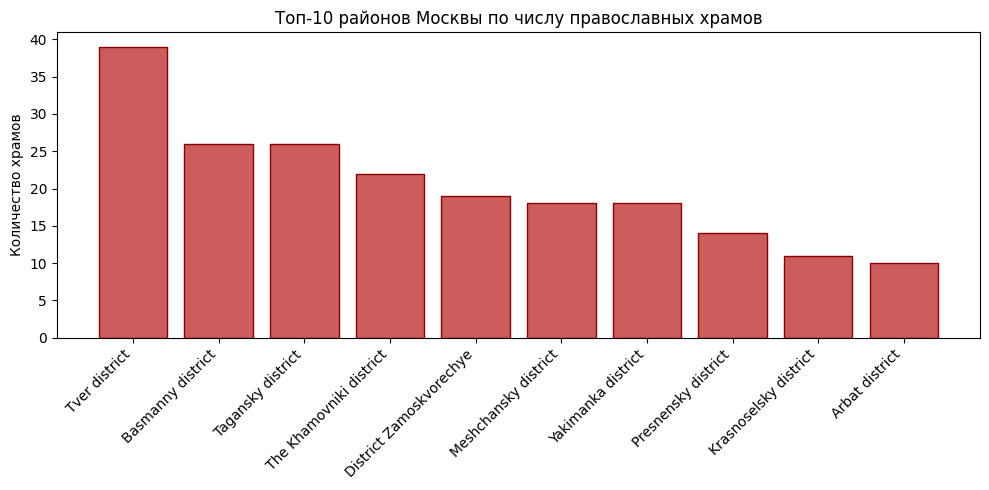

In [76]:
# Считаем храмы по районам, берём первые 10
top_districts = df['District'].value_counts().head(10)

# Визуализация
plt.figure(figsize=(10, 5))
plt.bar(range(len(top_districts)), top_districts.values, color='indianred', edgecolor='darkred')

# plt.xticks() задаёт подписи по оси X.
# rotation=45, ha='right' — поворачиваем подписи на 45 градусов,
# чтобы длинные названия не налезали друг на друга.
plt.xticks(range(len(top_districts)), top_districts.index, rotation=45, ha='right')

plt.ylabel('Количество храмов')
plt.title('Топ-10 районов Москвы по числу православных храмов')
plt.tight_layout()
plt.show()

---
#### Задание 7 (финальное)

Вопрос:
Правда ли, что храмы в честь святителя Николая Мирликийского (одного из самых почитаемых святых на Руси) равномерно распределены по всей Москве, или их концентрация заметно выше в историческом центре, где исторически располагалось больше купеческих слобод?

Используя изученные на семинаре методы фильтрации строк и визуализации, выполните следующие шаги:

1. Отфильтруйте датафрейм, оставив только те строки, в названии которых `(Name)` упоминается имя `'Nikolai'`.

2. Постройте интерактивную карту `folium` только для этих объектов. Для наглядности используйте маркеры яркого цвета (например, `red`). Поиграйте с визуальной составляющей, цветами и маркерами.

3. Посмотрите на получившееся пространственное распределение точек. Напишите краткий вывод: подтверждается ли гипотеза о высокой концентрации Никольских храмов в пределах Садового кольца (исторического ядра города)?

Отправьте результат скриншот в телеграм.

In [89]:
# ВАШ КОД

---
### Итоги

Сегодня мы:
1. Научились загружать и очищать табличные данные (чиним координаты, проверяем пропуски)
2. Закрепили фильтрацию, группировку и сортировку в pandas
3. Построили интерактивные карты: маркеры, раскраска по категориям, тепловая карта
4. Увидели пространственное распределение храмов Москвы и подумали о причинах неравномерности

### Документация
* folium: https://python-visualization.github.io/folium/
* pandas: https://pandas.pydata.org/docs/
* matplotlib: https://matplotlib.org/stable/contents.html

### Материалы для дальнейшего изучения

* **GeoPandas** расширение `pandas` для работы с пространственными данными. Добавляет специальный тип данных `GeoSeries` и `GeoDataFrame` для хранения геометрических объектов (точек, линий, полигонов). Позволяет выполнять пространственные запросы (например, определять, находится ли точка внутри полигона).
* **Shapely** библиотека для анализа и манипулирования геометрическими объектами на плоскости. Используется внутри `GeoPandas` для вычисления площадей, расстояний, пересечений и объединений геометрических фигур.
* **[The Spatial History Project (Stanford University)](https://spatialhistory.stanford.edu/)** — классические зарубежные кейсы и визуализации, демонстрирующие, как пространственный анализ помогает изучать историю урбанизации и социальные изменения.
* **[Портал открытых данных Правительства Москвы](https://data.mos.ru/)** — верифицированные реестры объектов городской инфраструктуры с географическими координатами, включая памятники истории и архитектуры.
* **[Retromap](http://retromap.ru/)** — уникальный ресурс со старинными картами Москвы и других регионов, позволяющий сопоставлять историческую топографию с современными спутниковыми снимками.